# 02 — Temporal Validation Setup

Decide *how* we will measure model quality before we build any models, so future experiments are
compared on the same, honest footing.

## 1. Why temporal validation (and not random K-fold)?

The test set contains time steps 36–49, all **after** the training steps 1–35. A model will be trained on the
past and asked to score the future.

Random K-fold would mix steps, so the model would be validated on transactions from the same weeks it was trained
on. That is easier than the real task, for two reasons we saw in the EDA:

- **Transactions within a step are connected.** Edges only link transactions in the same step, so a random split
  puts neighbours (often parts of the same illicit chain) on both sides. The model can then "recognise" a pattern
  it has already seen, instead of generalising to it.
- **The data changes over time.** The illicit rate ranges from about 1% to 36% between steps, and illicit
  behaviour itself changes. A random split hides that drift, so it would overstate how well a model works on
  future steps.

So we copy the real situation: **fit on early steps, validate on the latest steps.**

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_train, labeled, FEATURE_COLS, TIME_COL, LABEL_COL, SEED
from src.validation import temporal_split, evaluate, per_step_auc, TRAIN_END, VAL_END

C_FIT, C_VAL, C_ILLICIT, C_MUTED = "#2a78d6", "#1baf7a", "#eb6834", "#898781"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.edgecolor": C_MUTED, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})

train = load_train()
lab = labeled(train)
print("labeled training rows:", len(lab), "| illicit:", lab[LABEL_COL].sum())

labeled training rows: 31235 | illicit: 3644


## 2. Choosing where to split

We need to pick `train_end`: steps `1..train_end` are used for fitting, and `train_end+1..35` for validation.
There is a trade-off:

- **Later split →** more data to fit on, but fewer validation rows, so the AUC estimate is noisier.
- **Earlier split →** a more reliable validation estimate, but the model learns from less (and older) data.

The table compares a few candidates.

In [2]:
per_step = lab.groupby(TIME_COL)[LABEL_COL].agg(n="size", n_illicit="sum")

rows = []
for end in [19, 21, 24, 27, 30]:
    fit, val = per_step.loc[:end], per_step.loc[end + 1:]
    rows.append({
        "train_end": end,
        "fit steps": f"1-{end}", "val steps": f"{end + 1}-35", "n val steps": len(val),
        "fit rows": fit.n.sum(), "fit illicit": fit.n_illicit.sum(),
        "val rows": val.n.sum(), "val illicit": val.n_illicit.sum(),
        "val illicit rate": round(val.n_illicit.sum() / val.n.sum(), 3),
    })
pd.DataFrame(rows).set_index("train_end")

,fit steps,val steps,n val steps,fit rows,fit illicit,val rows,val illicit,val illicit rate
train_end,,,,,,,,
19,1-19,20-35,16,17989,1511,13246,2133,0.161
21,1-21,22-35,14,19530,1871,11705,1773,0.151
24,1-24,25-35,11,23606,2219,7629,1425,0.187
27,1-27,28-35,8,24923,2457,6312,1187,0.188
30,1-30,31-35,5,26905,2954,4330,690,0.159


**Choice: fit on steps 1–24, validate on steps 25–35.**

- It mirrors the real task: we know 35 steps and must predict 14 future ones. Here the model knows 24 steps and
  predicts 11 future ones, so the "distance into the future" is similar.
- The validation window still has about 7,600 labeled rows and **about 1,400 illicit** ones, enough for a stable
  overall AUC. Every validation step has at least 23 illicit rows, so per-step AUC is defined everywhere.
- The fit window still contains about 75% of the labeled data, including the high-illicit periods around steps 9–20.

These defaults are `TRAIN_END = 24` and `VAL_END = 35` in `src/validation.py`. After choosing a model with this
split, the final model is **retrained on all of steps 1–35** before predicting the test set.

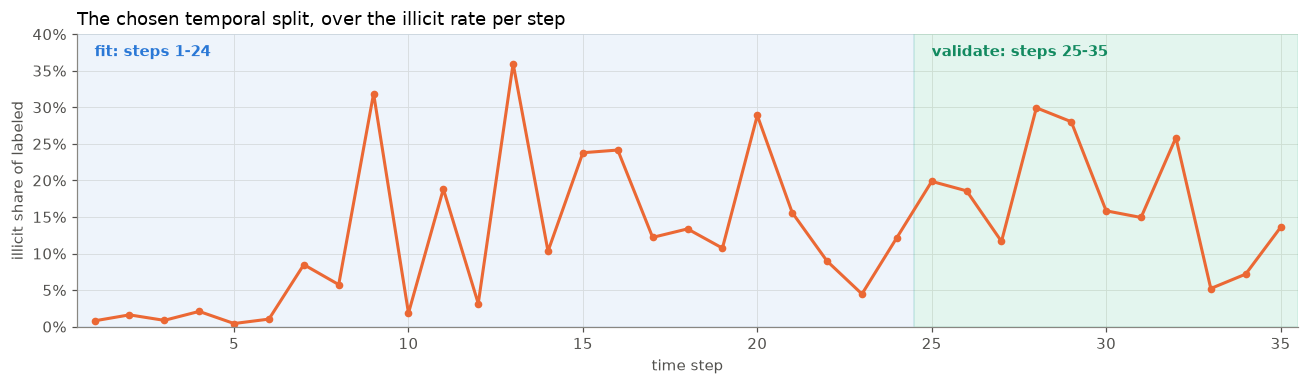

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.6))
rate = per_step.n_illicit / per_step.n
ax.axvspan(0.5, TRAIN_END + 0.5, color=C_FIT, alpha=0.08)
ax.axvspan(TRAIN_END + 0.5, VAL_END + 0.5, color=C_VAL, alpha=0.12)
ax.plot(rate.index, rate.values, color=C_ILLICIT, lw=2, marker="o", ms=4)
ax.text(1, 0.37, f"fit: steps 1-{TRAIN_END}", color=C_FIT, fontweight="bold")
ax.text(TRAIN_END + 1, 0.37, f"validate: steps {TRAIN_END + 1}-{VAL_END}", color="#138a60", fontweight="bold")
ax.set_ylim(0, 0.4); ax.set_xlim(0.5, VAL_END + 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("time step"); ax.set_ylabel("illicit share of labeled")
ax.set_title("The chosen temporal split, over the illicit rate per step", loc="left")
plt.tight_layout(); plt.show()

## 3. How `evaluate()` works

```python
result = evaluate(model, features, train)
```

1. **Split.** `temporal_split` drops unlabeled rows, then puts steps ≤ 24 into *fit* and steps 25–35 into *validation*.
2. **Fit.** It fits a fresh copy of the model (via `sklearn.base.clone`) on the fit rows, so the model object you pass in
   is never changed and every call starts from scratch.
3. **Predict.** It predicts the probability of "illicit" for the validation rows.
4. **Score.** It reports:
   - `overall_auc`: one ROC-AUC over all validation rows pooled together. **This is our headline number,** because
     Kaggle also computes a single AUC over all test rows.
   - `per_step`: AUC for each validation step on its own, with its row and illicit counts.
   - `mean_step_auc` / `std_step_auc`: the average and spread of the per-step AUCs. A large spread means the model
     is unstable over time, even if the pooled AUC looks good.

Note that the pooled and the per-step AUC answer slightly different questions. Pooled AUC also rewards a model for
ranking rows correctly *across* steps. Per-step AUC only checks the ranking within each step.

It also has a safety check: it raises an error if `time_step` is in the feature list.

## 4. Sanity checks

**Check 1 — no overlap between fit and validation**, and only labeled rows are used.

In [4]:
fit, val = temporal_split(train)
print("fit steps:", fit[TIME_COL].min(), "-", fit[TIME_COL].max(), "| rows:", len(fit), "| illicit:", fit[LABEL_COL].sum())
print("val steps:", val[TIME_COL].min(), "-", val[TIME_COL].max(), "| rows:", len(val), "| illicit:", val[LABEL_COL].sum())
assert fit[TIME_COL].max() < val[TIME_COL].min(), "fit and validation overlap in time"
assert not set(fit.txId) & set(val.txId), "a transaction is in both fit and validation"
assert fit[LABEL_COL].notna().all() and val[LABEL_COL].notna().all()
print("OK: no overlap, labeled rows only")

fit steps: 1 - 24 | rows: 23606 | illicit: 2219
val steps: 25 - 35 | rows: 7629 | illicit: 1425
OK: no overlap, labeled rows only


**Check 2 — `time_step` is rejected as a feature.**

In [5]:
from sklearn.linear_model import LogisticRegression

try:
    evaluate(LogisticRegression(), FEATURE_COLS + [TIME_COL], train)
except ValueError as err:
    print("OK, refused:", err)

OK, refused: time_step must not be used as a model feature


**Check 3 — a model with no information scores about 0.5.** A classifier that gives random scores should get an AUC
near 0.5 overall and in every step. If it scored well above 0.5, the evaluation code would be leaking information.

In [6]:
from sklearn.dummy import DummyClassifier

class RandomScorer(DummyClassifier):
    """Returns random probabilities: a model that knows nothing."""
    def predict_proba(self, X):
        rng = np.random.default_rng(SEED)
        p = rng.random(len(X))
        return np.column_stack([1 - p, p])

res_random = evaluate(RandomScorer(), FEATURE_COLS, train)
print(f"random scores -> overall AUC = {res_random['overall_auc']:.3f}, "
      f"per-step AUC range = {res_random['per_step'].auc.min():.2f} to {res_random['per_step'].auc.max():.2f}")

random scores -> overall AUC = 0.500, per-step AUC range = 0.43 to 0.60


The per-step AUCs of a random model spread around 0.5 quite a lot. Steps with few illicit rows (step 27 has 24)
give noisy AUCs **even for a model that does nothing**. Keep this noise level in mind when reading per-step results
for real models: a small dip in one small step is not necessarily meaningful.

**Check 4 — a real model runs end to end.** A plain logistic regression on all 165 features, just to check that the
pipeline and the outputs work. Proper baselines (and class weighting) are compared in `03_baseline_models.ipynb`,
so this result is not logged to `experiments.csv`.

In [7]:
res_lr = evaluate(LogisticRegression(max_iter=2000, random_state=SEED), FEATURE_COLS, train)

print(f"overall (pooled) AUC : {res_lr['overall_auc']:.4f}")
print(f"mean per-step AUC    : {res_lr['mean_step_auc']:.4f}  (std {res_lr['std_step_auc']:.4f})")
res_lr["per_step"].round(4)

overall (pooled) AUC : 0.9248
mean per-step AUC    : 0.9411  (std 0.0408)


,n,n_illicit,auc
time_step,,,
25,594,118,0.9762
26,517,96,0.9028
27,206,24,0.9799
28,284,85,0.9930
29,1174,329,0.9616
30,524,83,0.9611
31,710,106,0.8563
32,1323,342,0.9106
33,441,23,0.9474


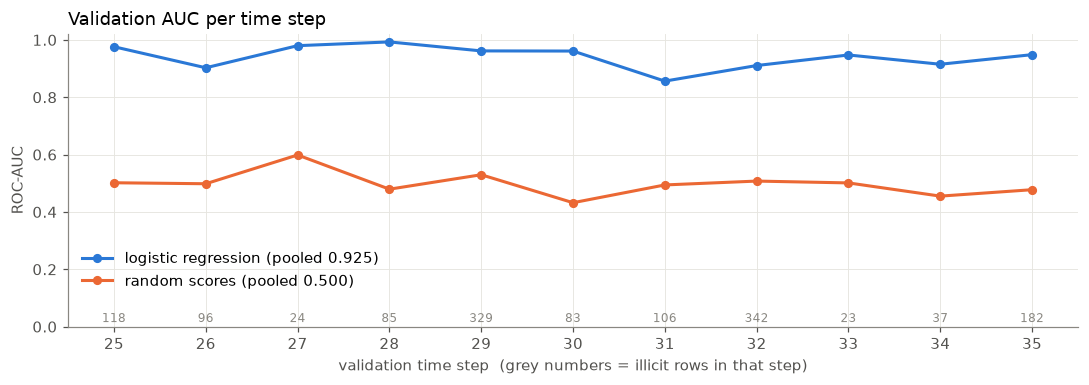

In [8]:
def plot_per_step(results, title):
    """Per-step validation AUC for one or more models. `results` maps a model name to the output of evaluate()."""
    colors = [C_FIT, C_ILLICIT, C_VAL, "#eda100"]
    fig, ax = plt.subplots(figsize=(10, 3.6))
    for (name, res), color in zip(results.items(), colors):
        s = res["per_step"]
        ax.plot(s.index, s.auc, marker="o", ms=5, lw=2, color=color,
                label=f"{name} (pooled {res['overall_auc']:.3f})")
    s = next(iter(results.values()))["per_step"]
    for step, n_ill in s.n_illicit.items():  # how many illicit rows each step's AUC is based on
        ax.annotate(f"{n_ill}", (step, 0), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8, color=C_MUTED)
    ax.set_ylim(0, 1.02); ax.set_xticks(s.index)
    ax.set_xlabel("validation time step  (grey numbers = illicit rows in that step)")
    ax.set_ylabel("ROC-AUC")
    ax.set_title(title, loc="left")
    ax.legend(loc="lower left", bbox_to_anchor=(0, 0.08))
    plt.tight_layout(); plt.show()

plot_per_step({"logistic regression": res_lr, "random scores": res_random},
              "Validation AUC per time step")

Logistic regression ranks transactions well in every validation step (AUC 0.86–0.99), far
above the random baseline. Its **pooled AUC (0.925) is lower than its mean per-step AUC (0.941)**. Within each step
the ranking is good, but the score *levels* are not consistent between steps. For example, a licit transaction in
one step can get a higher score than an illicit one in another step. Since Kaggle scores all test steps pooled
together, models that give consistent scores over time will benefit. This is something to watch as we compare models.

## Summary

- **Split:** fit on labeled rows of steps 1–24, validate on labeled rows of steps 25–35. There is no overlap and no
  edge crosses steps, so no information leaks from validation into fitting.
- **Metrics:** pooled validation AUC is the headline (it matches Kaggle's metric). Per-step AUC and its spread show
  stability over time.
- **Guards:** `time_step` cannot be used as a feature, and the model is cloned on every call so results are
  reproducible (seed 42).
- **Caveat:** per-step AUC is noisy for steps with few illicit rows, as the random-score check shows. Judge stability
  by the overall pattern, not single steps.
- **Final models** are retrained on all labeled steps 1–35 before predicting the test set.